# Day 1: Complex numbers

**Tue, Oct 6 · Prep · about 45 minutes**

Every amplitude in a quantum state is a complex number. Today is about getting fluent with them, both as algebra and as points on a plane.

**By the end of this notebook you can:**
- Add, multiply and conjugate complex numbers
- Move between a + bi and polar form r·e^(iθ)
- Explain why |z| = 1 numbers matter for qubits

> How to use this notebook: read each explanation, run the cell under it, then change the numbers and run it again.
> The exercises at the end have a "your turn" cell and a hidden worked solution. Try first, then check.

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
np.set_printoptions(precision=4, suppress=True)
plt.rcParams.update({"figure.figsize": (5, 5), "axes.grid": True, "grid.alpha": 0.3})

def tex(label):
    """Typeset a ket label like '|+>' as a proper |+⟩ in plots."""
    if label.startswith("|") and label.endswith(">"):
        return r"$|" + label[1:-1] + r"\rangle$"
    return label

## Symbols in this notebook
Not sure how to read something? Here's every symbol used below, with how to say it. The full dictionary is in [Day 0](00_reading_maths_symbols.ipynb).

| Symbol | Say it | Means |
|---|---|---|
| i | "i" | the imaginary unit; i × i = −1 |
| a + bi | "a plus b i" | a complex number with real part a and imaginary part b |
| z | "z" | the usual name for a complex number |
| z* or conj(z) | "z star", "conjugate of z" | a − bi: flip the sign of the imaginary part |
| \|z\| | "mod z" | the length of z: √(a² + b²) |
| r | "r" | the length again, in polar form |
| θ | "theta" | the angle from the positive real axis |
| e^(iθ) | "e to the i theta" | cos θ + i sin θ: a point on the unit circle |
| π | "pi" | 3.14159…; π radians = 180° |
| √ | "square root" |  |

## Back to basics: why do we need i at all?
Ordinary ("real") numbers live on a line. There's no real number whose square is −1, because any real number squared is ≥ 0.
Mathematicians simply **defined** a new number i with i² = −1 and found that everything still works. Adding a second axis for multiples of i turns the number line into a number **plane**.

**Powers of i cycle every four steps**, and this pattern is worth remembering:
- i¹ = i
- i² = −1 (the definition)
- i³ = i² · i = −1 · i = −i
- i⁴ = i² · i² = (−1)(−1) = 1
- i⁵ = i⁴ · i = i, and the cycle repeats

**Solving with i:** x² = −9 has no real answer, but x = 3i works: (3i)² = 9 · i² = 9 · (−1) = −9. ✓

In [2]:
for n in range(1, 9):
    print(f"i^{n} = {1j**n}")

i^1 = 1j
i^2 = (-1+0j)
i^3 = (-0-1j)
i^4 = (1+0j)
i^5 = 1j
i^6 = (-1+0j)
i^7 = (-0-1j)
i^8 = (1+0j)


## 1. A complex number is a point on a plane
`z = a + bi` has a **real part** `a` and an **imaginary part** `b`, where `i² = −1`.
Plot `a` on the horizontal axis and `b` on the vertical axis and every complex number becomes a point (or an arrow from the origin).

Python has complex numbers built in; it writes `i` as `j`.

In [3]:
z = 3 + 4j
print("z =", z)
print("real part:", z.real, " imaginary part:", z.imag)
print("i squared:", 1j * 1j)

z = (3+4j)
real part: 3.0  imaginary part: 4.0
i squared: (-1+0j)


## 2. Arithmetic
- **Add** component by component: (1 + 2i) + (3 − i) = 4 + i
- **Multiply** like brackets, then use i² = −1: (1 + 2i)(3 − i) = 3 − i + 6i − 2i² = 5 + 5i
- **Conjugate** flips the sign of the imaginary part: conj(a + bi) = a − bi (a reflection across the real axis)

In [4]:
w1, w2 = 1 + 2j, 3 - 1j
print("sum:       ", w1 + w2)
print("product:   ", w1 * w2)
print("conjugate: ", np.conj(w1))

sum:        (4+1j)
product:    (5+5j)
conjugate:  (1-2j)


## 3. Modulus: the length of the arrow
`|z| = √(a² + b²)`. A neat identity you'll use constantly: **z · conj(z) = |z|²**, always a real number.
In quantum computing, |amplitude|² is a probability, so this identity is how probabilities come out of complex amplitudes.

In [5]:
z = 3 + 4j
print("|z| =", abs(z))
print("z * conj(z) =", z * np.conj(z), "  (equals |z|^2 =", abs(z)**2, ")")

|z| = 5.0
z * conj(z) = (25+0j)   (equals |z|^2 = 25.0 )


## 4. Polar form and Euler's formula
Any point can also be described by its length `r` and its angle `θ` from the positive real axis:

`z = r(cos θ + i sin θ) = r·e^(iθ)`

The second equality is **Euler's formula**, e^(iθ) = cos θ + i sin θ. It turns rotation into multiplication:
multiplying by e^(iθ) rotates a number by θ without changing its length. Quantum gates use exactly this.

In [6]:
z = 1 + 1j
r, theta = abs(z), np.angle(z)
print(f"r = {r:.4f}, theta = {theta:.4f} rad = {np.degrees(theta):.1f} deg")
print("back to a+bi:", r * np.exp(1j * theta))

r = 1.4142, theta = 0.7854 rad = 45.0 deg
back to a+bi: (1.0000000000000002+1j)


### Picture it: a number, its conjugate, and the unit circle

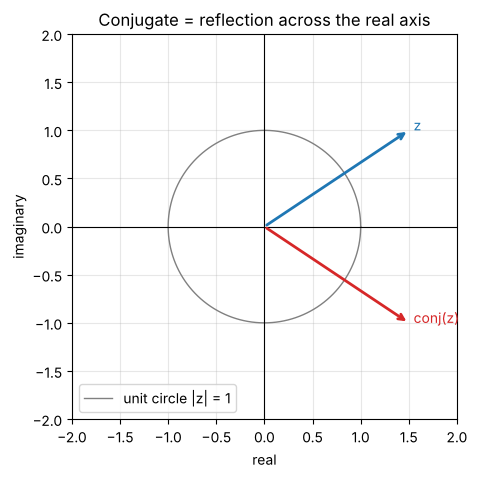

In [7]:
z = 1.5 + 1.0j
t = np.linspace(0, 2*np.pi, 300)
fig, ax = plt.subplots()
ax.plot(np.cos(t), np.sin(t), lw=1, color="gray", label="unit circle |z| = 1")
for val, lab, c in [(z, "z", "C0"), (np.conj(z), "conj(z)", "C3")]:
    ax.annotate("", xy=(val.real, val.imag), xytext=(0, 0), arrowprops=dict(arrowstyle="->", color=c, lw=2))
    ax.text(val.real + 0.05, val.imag, lab, color=c)
ax.axhline(0, color="k", lw=0.8); ax.axvline(0, color="k", lw=0.8)
ax.set_xlim(-2, 2); ax.set_ylim(-2, 2); ax.set_aspect("equal")
ax.set_xlabel("real"); ax.set_ylabel("imaginary"); ax.legend(loc="lower left")
ax.set_title("Conjugate = reflection across the real axis")
plt.show()

### Rotation by multiplying with e^(iθ)
Below, the same point is multiplied by e^(iπ/4) eight times. Each step rotates it 45° and the length never changes.

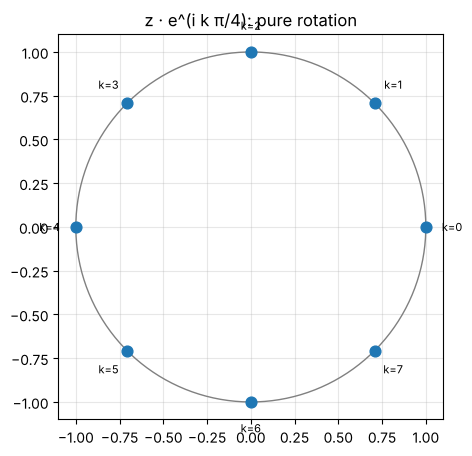

lengths: [np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0)]


In [8]:
z = 1 + 0j
pts = [z * np.exp(1j * k * np.pi / 4) for k in range(8)]
fig, ax = plt.subplots()
ax.plot(np.cos(t), np.sin(t), lw=1, color="gray")
ax.scatter([p.real for p in pts], [p.imag for p in pts], s=60, zorder=3)
for k, p in enumerate(pts):
    ax.text(p.real * 1.15, p.imag * 1.15, f"k={k}", ha="center", va="center", fontsize=8)
ax.set_aspect("equal"); ax.set_title("z · e^(i k π/4): pure rotation")
plt.show()
print("lengths:", [round(abs(p), 6) for p in pts])

## 5. Why this matters for qubits
A qubit state is `α|0⟩ + β|1⟩` with complex α and β. The probabilities are |α|² and |β|², and they must add to 1.
Two states that differ only by multiplying everything by e^(iθ) (a **global phase**) give identical probabilities. You'll meet this again on Day 11.

## Worked example, every step shown: multiplying (2 + 3i)(1 − 4i)
Treat it like multiplying two brackets (first, outer, inner, last), then replace every i² with −1.

1. First terms: 2 × 1 = 2
2. Outer terms: 2 × (−4i) = −8i
3. Inner terms: 3i × 1 = 3i
4. Last terms: 3i × (−4i) = −12i²
5. Replace i² with −1: −12i² = −12 × (−1) = +12
6. Collect real parts: 2 + 12 = 14
7. Collect imaginary parts: −8i + 3i = −5i
8. **Answer: 14 − 5i**

In [9]:
print((2 + 3j) * (1 - 4j))

(14-5j)


## Worked example, every step shown: converting 1 + i√3 to polar form
1. Real part a = 1, imaginary part b = √3 ≈ 1.732.
2. Length: r = √(a² + b²) = √(1 + 3) = √4 = **2**.
3. Angle: tan θ = b/a = √3. The point is in the upper-right quarter, and the angle whose tangent is √3 is 60°, so **θ = π/3**.
4. **Polar form: 2·e^(iπ/3)**.
5. Check going back: 2(cos 60° + i sin 60°) = 2(0.5 + 0.866i) = 1 + 1.732i ✓

In [10]:
z = 1 + 1j * np.sqrt(3)
print("r =", abs(z), " theta =", np.angle(z), " pi/3 =", np.pi / 3)
print("back again:", 2 * np.exp(1j * np.pi / 3))

r = 2.0  theta = 1.0471975511965976  pi/3 = 1.0471975511965976
back again: (1.0000000000000002+1.7320508075688772j)


### Common mistakes
- Forgetting that i² = −1 and leaving i² in the answer.
- Writing |a + bi| = a + b. It's √(a² + b²): |3 + 4i| = 5, not 7.
- Mixing degrees and radians. NumPy's `np.angle`, `np.cos` and `np.exp` all use radians.

## Exercises
**E1.** Write (1 + i)/√2 in polar form and show its modulus is 1.

**E2.** Compute (2 + 3i)(2 − 3i). Why is the answer real?

**E3.** What happens to a complex number when you multiply it by i? Describe it as a rotation.

In [11]:
# Your turn: use Python to check your hand-worked answers
z = (1 + 1j) / np.sqrt(2)
# print(abs(z), np.angle(z))

<details>
<summary><b>Show worked solution</b></summary>

**E1.** a = b = 1/√2, so r = √(1/2 + 1/2) = 1 and θ = arctan(1) = π/4. So (1 + i)/√2 = e^(iπ/4).

**E2.** (2 + 3i)(2 − 3i) = 4 − 6i + 6i − 9i² = 4 + 9 = 13. A number times its conjugate is always |z|², which is real.

**E3.** i = e^(iπ/2), so multiplying by i rotates the arrow 90° anticlockwise. Example: 1 → i → −1 → −i → 1.

</details>

In [12]:
# Automatic check of the solutions
z = (1 + 1j) / np.sqrt(2)
assert np.isclose(abs(z), 1) and np.isclose(np.angle(z), np.pi / 4)
assert (2 + 3j) * (2 - 3j) == 13
assert np.isclose(1j * (1 + 0j), np.exp(1j * np.pi / 2))
print("All Day 1 checks passed.")

All Day 1 checks passed.


---
### Recap checklist
Tick these off in your head before moving on. If any feel shaky, re-run the relevant section with your own numbers.

**Next:** Day 2: Linear algebra 1, vectors and inner products

*Part of the IIT Delhi CEP Applied Quantum Computing & AI prep plan: [prep-plan.md](../plan/prep-plan.md)*